<a href="https://colab.research.google.com/github/ilhambdg/KDKA_UAS/blob/main/KDKA_PROJECT_AKHIR_RILLLL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "shibghoh"
os.environ['KAGGLE_KEY'] = "KGAT_184de4d13ea488dbdf93ab824415c639"

!pip install -q kaggle

In [ ]:
!kaggle datasets download -d balraj98/deepglobe-land-cover-classification-dataset

import zipfile

with zipfile.ZipFile('deepglobe-land-cover-classification-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset_kaggle')

print("Selesai! File sudah diekstrak ke folder 'dataset_kaggle'")

Dataset URL: https://www.kaggle.com/datasets/balraj98/deepglobe-land-cover-classification-dataset
License(s): other
100% 2.74G/2.74G [00:15<00:00, 191MB/s]

Selesai! File sudah diekstrak ke folder 'dataset_kaggle'


In [ ]:
def euclidean(a, b):
    return np.sqrt(np.sum((a-b)**2))

def manhattan_numpy(a, b):
    return np.sum(np.abs(a - b))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import cv2

img_gt = Image.open('/content/dataset_kaggle/train/154626_mask.png')

img = Image.open('/content/dataset_kaggle/train/154626_sat.jpg')
img = img.resize((256, 256))

img_gry = cv2.cvtColor(np.array(img), cv2.COLOR_BGR2GRAY)

img_rgb = img.convert('RGB')
img_hsv = img.convert('HSV')

img_np_rgb = np.array(img_rgb)
img_np_hsv = np.array(img_hsv)

# img_np_rgb = img_np_rgb[:, :, :3]
# img_np_hsv = img_np_hsv[:, :, :3]

pixel_gry = img_gry.reshape(-1)
pixel_rgb = img_np_rgb.reshape(-1, 3)
pixel_hsv = img_np_hsv.reshape(-1, 3)

array([[[ 98, 104,  82],
        [ 97, 105,  82],
        [ 96, 104,  80],
        ...,
        [ 88, 101,  84],
        [100, 106,  90],
        [ 99, 106,  89]],

       [[ 97, 105,  82],
        [ 96, 105,  82],
        [ 96, 104,  80],
        ...,
        [ 89,  97,  79],
        [ 80,  93,  76],
        [ 85,  91,  76]],

       [[ 96, 104,  82],
        [ 94, 105,  81],
        [ 97, 105,  81],
        ...,
        [ 89,  99,  84],
        [ 79,  97,  76],
        [ 93,  95,  76]],

       ...,

       [[ 77,  85,  71],
        [ 77,  89,  74],
        [ 81,  90,  72],
        ...,
        [109,  97,  76],
        [106,  95,  76],
        [104,  93,  74]],

       [[ 83,  84,  71],
        [ 88,  91,  77],
        [101,  96,  79],
        ...,
        [106,  96,  75],
        [101,  92,  72],
        [ 98,  91,  72]],

       [[ 95,  95,  78],
        [ 96,  93,  77],
        [100,  93,  79],
        ...,
        [ 97,  91,  72],
        [ 95,  87,  69],
        [ 96,  89,  70]]], dtype=uint8)
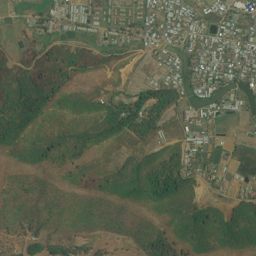

In [ ]:
img_np_rgb

array([[[ 54,  53, 104],
        [ 57,  55, 105],
        [ 56,  58, 104],
        ...,
        [ 75,  42, 101],
        [ 58,  38, 106],
        [ 60,  40, 106]],

       [[ 57,  55, 105],
        [ 59,  55, 105],
        [ 56,  58, 104],
        ...,
        [ 61,  47,  97],
        [ 75,  46,  93],
        [ 59,  42,  91]],

       [[ 57,  53, 104],
        [ 61,  58, 105],
        [ 56,  58, 105],
        ...,
        [ 70,  38,  99],
        [ 78,  55,  97],
        [ 46,  51,  95]],

       ...,

       [[ 66,  42,  85],
        [ 76,  42,  89],
        [ 63,  51,  90],
        ...,
        [ 27,  77, 109],
        [ 26,  72, 106],
        [ 26,  73, 104]],

       [[ 45,  39,  84],
        [ 51,  39,  91],
        [ 32,  55, 101],
        ...,
        [ 28,  74, 106],
        [ 29,  73, 101],
        [ 31,  67,  98]],

       [[ 42,  45,  95],
        [ 35,  50,  96],
        [ 28,  53, 100],
        ...,
        [ 32,  65,  97],
        [ 29,  69,  95],
        [ 31,  69,  96]]], dtype=uint8)
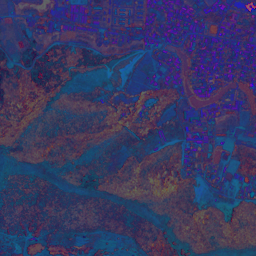

In [ ]:
img_np_hsv

array([[ 97,  97,  96, ...,  94, 101, 100],
       [ 97,  97,  96, ...,  91,  86,  86],
       [ 97,  97,  97, ...,  93,  89,  89],
       ...,
       [ 80,  83,  84, ...,  92,  91,  89],
       [ 80,  86,  91, ...,  91,  87,  86],
       [ 90,  89,  90, ...,  86,  83,  84]], dtype=uint8)
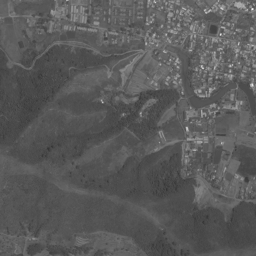

In [ ]:
img_gry

In [ ]:
pixel_hsv.shape, pixel_rgb.shape, pixel_gry.shape

((65536, 3), (65536, 3), (65536,))

In [ ]:
pixel_gry = pixel_gry.reshape(-1, 1)
pixel_gry.shape

(65536, 1)

In [ ]:
import numpy as np

def inisialisasi_centroid(data, threshold_manual, max_k=3):

    idx_awal = np.random.choice(len(data))
    centroids = [data[idx_awal]]

    for i in range(1, max_k):

        dist_ke_semua_centroid = np.sum((data[:, np.newaxis, :] - np.array(centroids)) ** 2, axis=2)


        dist_terdekat = np.min(dist_ke_semua_centroid, axis=1)

        idx_melebihi_threshold = np.where(dist_terdekat > threshold_manual)[0]

        if len(idx_melebihi_threshold) == 0:
            break

        idx_maksimum = idx_melebihi_threshold[np.argmax(dist_terdekat[idx_melebihi_threshold])]
        centroids.append(data[idx_maksimum])


    return np.array(centroids)

jarak_batas = 450

centroid_rgb = inisialisasi_centroid(pixel_rgb, jarak_batas)
centroid_hsv = inisialisasi_centroid(pixel_hsv, jarak_batas)
centroid_gry_2d = inisialisasi_centroid(pixel_gry, jarak_batas)

centroid_gry = centroid_gry_2d.flatten() if centroid_gry_2d.shape[1] == 1 else centroid_gry_2d

print(f"Jumlah K RGB: {len(centroid_rgb)}")
print(f"Jumlah K HSV: {len(centroid_hsv)}")
print(f"Jumlah K Grayscale: {len(centroid_gry)}")


Jumlah K RGB: 3
Jumlah K HSV: 3
Jumlah K Grayscale: 1


In [ ]:
def KMeans_euclidean(pixel, centroid):
  converged = False
  q=1
  while not converged:
    print(f"Iterasi ke-{q}")
    q+=1
    label = []

    for p in pixel:
      jarak = []
      for c in centroid:
        jarak.append(euclidean(p, c))
      label.append(np.argmin(jarak))

    label = np.array(label)
    old_centroid = centroid.copy()
    new_centroid = []

    for i in range(centroid.shape[0]):
      cluster_pixels = pixel[label == i]

      if len(cluster_pixels) > 0:
        new_centroid.append(np.mean(cluster_pixels, axis = 0))
      else:
        new_centroid.append(centroid[i])

    centroid = np.array(new_centroid)

    if np.allclose(old_centroid, centroid):
      converged = True


  return label, centroid


In [ ]:
label_hsv, centroid_hsv = KMeans_euclidean(pixel_hsv, centroid_hsv)
label_rgb, centroid_rgb = KMeans_euclidean(pixel_rgb, centroid_rgb)
label_gry, centroid_gry = KMeans_euclidean(pixel_gry, centroid_gry)

Iterasi ke-1
Iterasi ke-2
Iterasi ke-3
Iterasi ke-4
Iterasi ke-5
Iterasi ke-6
Iterasi ke-7
Iterasi ke-8
Iterasi ke-9
Iterasi ke-10
Iterasi ke-11
Iterasi ke-12
Iterasi ke-13
Iterasi ke-14
Iterasi ke-15
Iterasi ke-16
Iterasi ke-17
Iterasi ke-18
Iterasi ke-19
Iterasi ke-20
Iterasi ke-21
Iterasi ke-22
Iterasi ke-23
Iterasi ke-24
Iterasi ke-1
Iterasi ke-2
Iterasi ke-3
Iterasi ke-4
Iterasi ke-5
Iterasi ke-6
Iterasi ke-7
Iterasi ke-8
Iterasi ke-9
Iterasi ke-10
Iterasi ke-11
Iterasi ke-12
Iterasi ke-13
Iterasi ke-14
Iterasi ke-15
Iterasi ke-16
Iterasi ke-17
Iterasi ke-18
Iterasi ke-19
Iterasi ke-20
Iterasi ke-21
Iterasi ke-22
Iterasi ke-23
Iterasi ke-24
Iterasi ke-25
Iterasi ke-26
Iterasi ke-27
Iterasi ke-28
Iterasi ke-29
Iterasi ke-30
Iterasi ke-31
Iterasi ke-32
Iterasi ke-33
Iterasi ke-34
Iterasi ke-35
Iterasi ke-36
Iterasi ke-1
Iterasi ke-2


In [ ]:
segmented_pixel_rgb = centroid_rgb[label_rgb].astype(np.uint8)
segmented_img_rgb = segmented_pixel_rgb.reshape(img_np_rgb.shape)

segmented_pixel_hsv = centroid_hsv[label_hsv].astype(np.uint8)
segmented_img_hsv = segmented_pixel_hsv.reshape(img_np_hsv.shape)

segmented_pixel_gry = centroid_gry[label_gry].astype(np.uint8)
segmented_img_gry = segmented_pixel_gry.reshape(img_gry.shape)

In [ ]:
warna_label = np.array([
    [0, 255, 255],  # urban_land
    [255, 255, 0],  # agriculture_land
    [255, 0, 255],  # rangeland
    [0, 255, 0],    # forest_land
    [0, 0, 255],    # water
    [255, 255, 255],# barren_land
    [0, 0, 0]       # unknown
], dtype=np.uint8)

warna_label_gry = np.array([
    [int(0.299*0 + 0.587*255 + 0.114*255)],  # urban_land
    [int(0.299*255 + 0.587*255 + 0.114*0)],  # agriculture_land
    [int(0.299*255 + 0.587*0 + 0.114*255)],  # rangeland
    [int(0.299*0 + 0.587*255 + 0.114*0)],    # forest_land
    [int(0.299*0 + 0.587*0 + 0.114*255)],    # water
    [int(0.299*255 + 0.587*255 + 0.114*255)],# barren_land
    [int(0.299*0 + 0.587*0 + 0.114*0)]       # unknown
], dtype=np.uint8)

custom_segmented_pixels_rgb = warna_label[label_rgb]
custom_segmented_img_rgb = custom_segmented_pixels_rgb.reshape(img_np_rgb.shape)

custom_segmented_pixels_hsv = warna_label[label_hsv]
custom_segmented_img_hsv = custom_segmented_pixels_hsv.reshape(img_np_hsv.shape)

custom_segmented_pixels_gry = warna_label_gry[label_gry]
custom_segmented_img_gry = custom_segmented_pixels_gry.reshape(img_gry.shape)

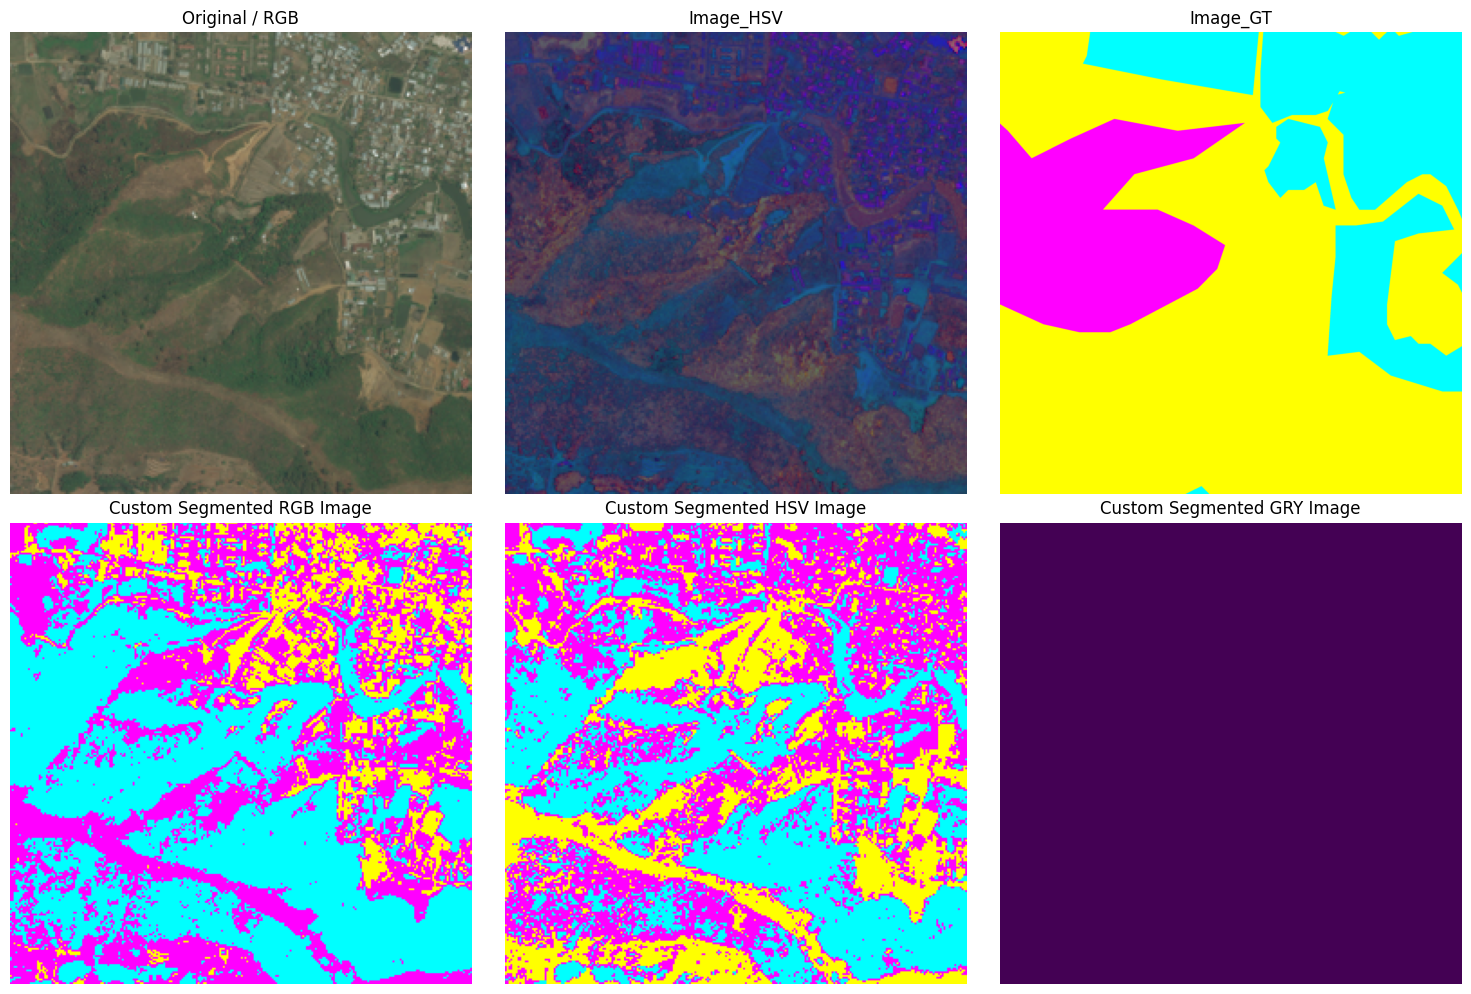

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("Original / RGB")
plt.imshow(img)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Image_HSV")
plt.imshow(img_np_hsv)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Image_GT")
plt.imshow(img_gt)
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Custom Segmented RGB Image")
plt.imshow(custom_segmented_img_rgb)
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Custom Segmented HSV Image")
plt.imshow(custom_segmented_img_hsv)
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Custom Segmented GRY Image")
plt.imshow(custom_segmented_img_gry)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def KMeans_loop(pixel, centroid, label):

  for i in range(centroid.shape[0]):
      pts = pixel[label == i]
      plt.scatter(pts[:, 0], pts[:, 1], label=f"Cluster {i}")

  plt.scatter(centroid[:, 0], centroid[:, 1], marker='x', s=150, label="Centroid")

  plt.title("K-Means (Loop Dasar - Konvergensi)")
  plt.legend()
  plt.show()

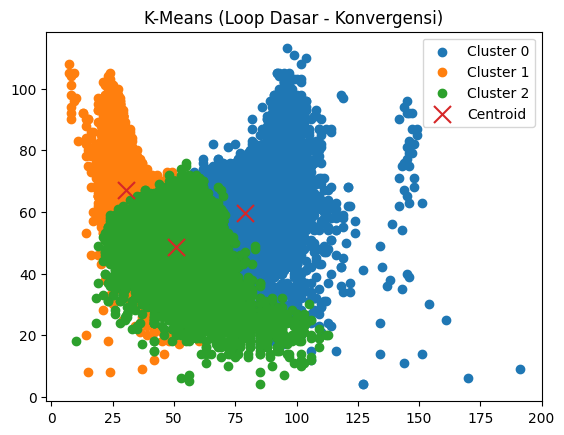

In [ ]:
KMeans_loop(pixel_hsv, centroid_hsv, label_hsv)

In [ ]:
gt_np = np.array(img_gt.convert('RGB'))

warna_unik_gt = np.unique(gt_np.reshape(-1, 3), axis=0)

gt_labels = np.zeros(gt_np.shape[:2], dtype=np.uint16)

for i, warna in enumerate(warna_unik_gt):
    match = np.all(gt_np == warna, axis=-1)
    gt_labels[match] = i

In [ ]:
from skimage.filters import threshold_multiotsu
import numpy as np

def multiotsu_init_rgb(pixel_rgb, pixel_gry, classes):

    thresholds = threshold_multiotsu(pixel_gry, classes=classes)

    labels = np.digitize(pixel_gry, bins=thresholds)

    centroids = []

    for i in range(classes):

        members = pixel_rgb[labels == i]

        if len(members) > 0:
            centroids.append(
                np.mean(members, axis=0)
            )

    return np.array(centroids)

def multiotsu_init_hsv(pixel_hsv, pixel_gry, classes):

    thresholds = threshold_multiotsu(pixel_gry, classes=classes)

    labels = np.digitize(pixel_gry, bins=thresholds)

    centroids = []

    for i in range(classes):

        members = pixel_hsv[labels == i]

        if len(members) > 0:
            centroids.append(
                np.mean(members, axis=0)
            )

    return np.array(centroids)

from skimage.filters import threshold_multiotsu

def multiotsu_init_gray(pixel_gry, classes):

    thresholds = threshold_multiotsu(
        pixel_gry,
        classes=classes
    )

    labels = np.digitize(
        pixel_gry,
        bins=thresholds
    )

    centroids = []

    for i in range(classes):

        members = pixel_gry[labels == i]

        if len(members) > 0:
            centroids.append(
                np.mean(members)
            )

    return np.array(centroids)

In [ ]:
pixel_gry = pixel_gry.reshape(-1)

In [ ]:
centroid_rgb_init = multiotsu_init_rgb(
    pixel_rgb,
    pixel_gry,
    classes= 3
)

label_rgb_otsu, centroid_rgb_otsu = KMeans_euclidean(
    pixel_rgb,
    centroid_rgb_init
)

Iterasi ke-1
Iterasi ke-2
Iterasi ke-3
Iterasi ke-4
Iterasi ke-5
Iterasi ke-6
Iterasi ke-7
Iterasi ke-8
Iterasi ke-9
Iterasi ke-10
Iterasi ke-11
Iterasi ke-12
Iterasi ke-13
Iterasi ke-14
Iterasi ke-15
Iterasi ke-16
Iterasi ke-17
Iterasi ke-18
Iterasi ke-19
Iterasi ke-20
Iterasi ke-21
Iterasi ke-22
Iterasi ke-23
Iterasi ke-24
Iterasi ke-25
Iterasi ke-26
Iterasi ke-27
Iterasi ke-28
Iterasi ke-29
Iterasi ke-30
Iterasi ke-31
Iterasi ke-32
Iterasi ke-33
Iterasi ke-34
Iterasi ke-35
Iterasi ke-36
Iterasi ke-37
Iterasi ke-38


In [ ]:
centroid_hsv_init = multiotsu_init_hsv(
    pixel_hsv,
    pixel_gry,
    classes= 3
)

label_hsv_otsu, centroid_hsv_otsu = KMeans_euclidean(
    pixel_hsv,
    centroid_hsv_init
)

Iterasi ke-1
Iterasi ke-2
Iterasi ke-3
Iterasi ke-4
Iterasi ke-5
Iterasi ke-6
Iterasi ke-7
Iterasi ke-8
Iterasi ke-9
Iterasi ke-10
Iterasi ke-11
Iterasi ke-12
Iterasi ke-13
Iterasi ke-14


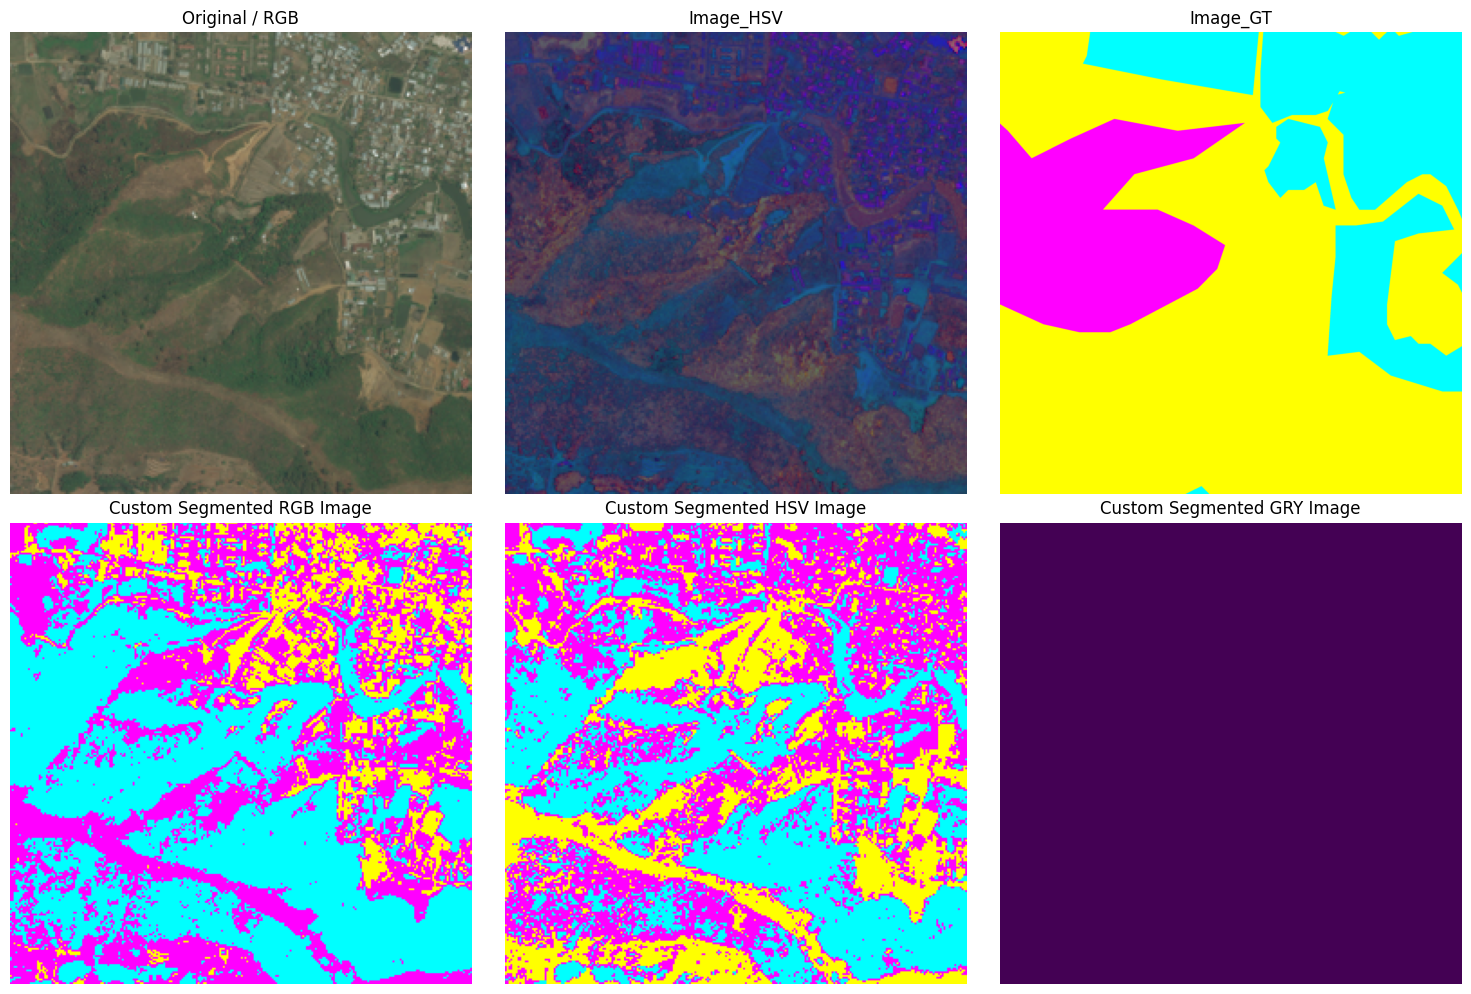

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("Original / RGB")
plt.imshow(img)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Image_HSV")
plt.imshow(img_np_hsv)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Image_GT")
plt.imshow(img_gt)
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Custom Segmented RGB Image")
plt.imshow(custom_segmented_img_rgb)
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Custom Segmented HSV Image")
plt.imshow(custom_segmented_img_hsv)
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Custom Segmented GRY Image")
plt.imshow(custom_segmented_img_gry)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import jaccard_score

if gt_labels.shape != (256, 256):
    gt_labels_resized = cv2.resize(gt_labels, (256, 256), interpolation=cv2.INTER_NEAREST)
else:
    gt_labels_resized = gt_labels

gt_flat = gt_labels_resized.flatten()
pred_rgb_flat = label_rgb.flatten()

iou_rgb_per_class = jaccard_score(gt_flat, pred_rgb_flat, average=None)
miou_rgb = np.mean(iou_rgb_per_class)

pred_hsv_flat = label_hsv.flatten()
iou_hsv_per_class = jaccard_score(gt_flat, pred_hsv_flat, average=None)
miou_hsv = np.mean(iou_hsv_per_class)

pred_gry_flat = label_gry.flatten()
iou_gry_per_class = jaccard_score(gt_flat, pred_gry_flat, average=None)
miou_gry = np.mean(iou_gry_per_class)

pred_rgb_flat_otsu = label_rgb_otsu.flatten()
iou_rgb_per_class_otsu = jaccard_score(gt_flat, pred_rgb_flat_otsu, average=None)
miou_rgb_otsu = np.mean(iou_rgb_per_class_otsu)

pred_hsv_flat_otsu = label_hsv_otsu.flatten()
iou_hsv_per_class_otsu = jaccard_score(gt_flat, pred_hsv_flat_otsu, average=None)
miou_hsv_otsu = np.mean(iou_hsv_per_class_otsu)


print(f"Mean IoU (mIoU) GRY : {miou_gry * 100:.2f}%")
print(f"Mean IoU (mIoU) RGB : {miou_rgb * 100:.2f}%")
print(f"Mean IoU (mIoU) HSV : {miou_hsv * 100:.2f}%")
print(f"Mean IoU (mIoU) RGB_m : {miou_rgb_otsu * 100:.2f}%")
print(f"Mean IoU (mIoU) HSV_m : {miou_hsv_otsu * 100:.2f}%")

Mean IoU (mIoU) GRY : 7.97%
Mean IoU (mIoU) RGB : 12.52%
Mean IoU (mIoU) HSV : 11.95%
Mean IoU (mIoU) RGB_m : 5.11%
Mean IoU (mIoU) HSV_m : 6.42%
